<h2>Utils</h2>

In [1]:
import sys
import os

import numpy
from fetch_movie_details import search_movie, get_movie_details, discover_movies, get_genre_mapping
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from fetch_movie_details import discover_movies
import pandas as pd

movies = discover_movies(page=1)

# Convert to DataFrame
df = pd.json_normalize(movies)

# Show just what you want
print(df[['title', 'release_date', 'vote_average']].head())
print(df.columns)
#print(df['genre_ids'])

                 title release_date  vote_average
0  Karate Kid: Legends   2025-05-08         7.184
1      The Old Guard 2   2025-07-01         6.132
2            Ballerina   2025-06-04         7.400
3       Heads of State   2025-07-02         6.975
4        Thunderbolts*   2025-04-30         7.435
Index(['adult', 'backdrop_path', 'genre_ids', 'id', 'original_language',
       'original_title', 'overview', 'popularity', 'poster_path',
       'release_date', 'title', 'video', 'vote_average', 'vote_count'],
      dtype='object')


<h2>Data Loading</h2>

In [3]:
def get_movie_data(max_pages):
    full_data = []
    for count in range(1, max_pages+1):
        for movie in discover_movies(page=count):  # or across multiple pages
            movie_id = movie['id']
            details = get_movie_details(movie_id)
            full_data.append(details)
        
        df = pd.json_normalize(full_data)
        df.to_csv('../data/movies_full.csv', index=False)


In [4]:
csv_path = "../data/movies_full.csv"
download_more_data = False

if os.path.exists(csv_path): #and not download_more_data:
    print("Already obtained data")
else:
    n = 50
    movie_df = get_movie_data(n)
    print("Obtained data!")

Already obtained data


In [5]:
# Useful columns: adult, budget, genres, origin country, original language, tagline, title, vote average, overview, popularity, revenue, runtime
csv_path = "../data/movies_full.csv"
movies = pd.read_csv(csv_path)
movies.head(1)

,adult,backdrop_path,budget,genres,homepage,id,imdb_id,origin_country,original_language,original_title,...,tagline,title,video,vote_average,vote_count,belongs_to_collection.id,belongs_to_collection.name,belongs_to_collection.poster_path,belongs_to_collection.backdrop_path,belongs_to_collection
0,False,/x58Gk2ZGU5AEBp25MQe2nhZhd5z.jpg,7000000,"[{'id': 28, 'name': 'Action'}, {'id': 14, 'nam...",https://www.netflix.com/title/81328881,846422,tt14961624,['US'],en,The Old Guard 2,...,Eternity has a price.,The Old Guard 2,False,6.156,269,847029.0,The Old Guard Collection,/9S7wx0F1skyjiQP2glvGUIa4uYU.jpg,/A7fKA5gQEUh2Rf9s4zaYyIpCU6o.jpg,NaN


In [7]:
movies.columns

Index(['adult', 'backdrop_path', 'budget', 'genres', 'homepage', 'id',
       'imdb_id', 'origin_country', 'original_language', 'original_title',
       'overview', 'popularity', 'poster_path', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title', 'video',
       'vote_average', 'vote_count', 'belongs_to_collection.id',
       'belongs_to_collection.name', 'belongs_to_collection.poster_path',
       'belongs_to_collection.backdrop_path', 'belongs_to_collection'],
      dtype='object')

<h2>Data Visualization</h2>

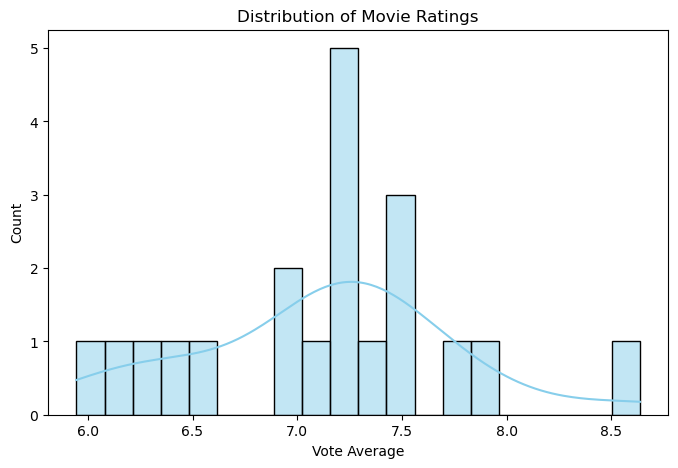

In [49]:
plt.figure(figsize=(8, 5))
sns.histplot(df["vote_average"], bins=20, kde=True, color='skyblue')
plt.title("Distribution of Movie Ratings")
plt.xlabel("Vote Average")
plt.ylabel("Count")
plt.show()

In [7]:
genre_map = get_genre_mapping()

In [8]:
def map_genre_ids_to_names(genre_ids_list):
    return [genre_map.get(genre_id, "Unknown") for genre_id in genre_ids_list]

df["genre_names"] = df["genre_ids"].apply(map_genre_ids_to_names)

In [9]:
print(df[["title", "genre_names"]].head())

                 title                           genre_names
0  Karate Kid: Legends            [Action, Adventure, Drama]
1      The Old Guard 2                     [Action, Fantasy]
2            Ballerina             [Action, Thriller, Crime]
3       Heads of State            [Action, Thriller, Comedy]
4        Thunderbolts*  [Action, Science Fiction, Adventure]


In [ ]:
from sklearn.model_selection import train_test_split
def get_train_valid_test_data():
    """ Randomizes and then splits the data into train, validation, and test sets.
    """
    X_trn, X_tst, y_trn, y_tst = train_test_split(X, y, train_size=.8, random_state=42)
    X_trn, X_vld, y_trn, y_vld = train_test_split(X_trn, y_trn, train_size=.8, random_state=42)

    return X_trn, y_trn, X_vld, y_vld, X_tst, y_tst